# ong2026 — Ong et al. (2026) — Universal 2NN Estimator

Global mean(log(log mu)) over all 2NN ratios.  Universal scale-free invariant.


## What the paper does

Proposes a **parameter-free** intrinsic-dimension estimator. For every point it forms the ratio `mu = r2 / r1` of its two nearest-neighbour distances; under a uniform-density assumption `mu` follows a known distribution, and the global estimate is simply `mean(log(log mu))` over all points — a scale-free invariant with no hyperparameters to tune.

**Methodology:** 2NN distance ratios `mu` → `mean(log(log mu))` → intrinsic dimension.

**Expected result:** the estimator recovers the true dimension across many test manifolds (Swiss roll, sphere, torus, …) without tuning (their Fig. 4 benchmark). No neural network is involved — it's about the estimator itself.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2603.10493](https://arxiv.org/abs/2603.10493)
- **Venue:** Preprint (Queen Mary / Oxford collaboration)
- **Datasets used:** Synthetic point clouds on Swiss roll, sphere, torus, and other test manifolds of known dimension.
- **Models used:** No NN involved — the paper is about the estimator itself; test data is sampled directly from manifolds.
- **Headline result to aim for:** The mean(log(log mu)) estimator converges to the true intrinsic dimension on every test distribution without tuning (their Fig. 4 benchmark table).
- **Reference code:** no public repo found in web search — check paper supplementary materials.

The synthetic manifolds in §1–3 validate the estimator against *known* dimensions; §4 then applies the identical pipeline to a real trained network's activations.  To profile your own model, hand a `torch.nn.Module` (or `ModelSnapshot`) to `pipe.fit_model(...)` — everything else stays the same.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `tanc` importable
import numpy as np
import matplotlib.pyplot as plt
from tanc import TDAPipeline
np.random.seed(0)


## 1. Synthetic data (swap in your real data here)


In [2]:
# Point clouds sampled from manifolds of KNOWN intrinsic dimension,
# isometrically embedded in a higher-dimensional ambient space.
rng = np.random.default_rng(0)

def embed(P, D):
    '''Rotate a d-D point set into D-D (random orthonormal embedding).'''
    Q = np.linalg.qr(rng.standard_normal((D, P.shape[1])))[0]
    return (P @ Q.T).astype(np.float32)

manifolds = {
    'line (d=1)':  (embed(rng.uniform(0, 1, (800, 1)), 10), 1),
    'plane (d=2)': (embed(rng.uniform(0, 1, (800, 2)), 10), 2),
    'cube (d=3)':  (embed(rng.uniform(0, 1, (800, 3)), 10), 3),
    'cube (d=5)':  (embed(rng.uniform(0, 1, (800, 5)), 10), 5),
}
# Swiss roll: a 2-D sheet curled into 3-D.
t = 1.5*np.pi*(1 + 2*rng.uniform(0, 1, 800)); h = 21*rng.uniform(0, 1, 800)
manifolds['swiss roll (d=2)'] = (np.c_[t*np.cos(t), h, t*np.sin(t)].astype(np.float32), 2)

data       = [v[0] for v in manifolds.values()]
true_dims  = [v[1] for v in manifolds.values()]
print('manifolds:', list(manifolds))


manifolds: ['line (d=1)', 'plane (d=2)', 'cube (d=3)', 'cube (d=5)', 'swiss roll (d=2)']


## 2. Reproduce in two lines via `TDAPipeline.from_paper`


In [3]:
pipe = TDAPipeline.from_paper("ong2026")
pipe.explain()


TDAPipeline — Ong et al. (2026)
  Stage 1: (skipped — direct dimension estimation)
  Stage 2: tool    = dimension
             method = 'calibrated'
             estimator = 'activation_id'
  Default plot   : .plot('id_layers')


"TDAPipeline — Ong et al. (2026)\n  Stage 1: (skipped — direct dimension estimation)\n  Stage 2: tool    = dimension\n             method = 'calibrated'\n             estimator = 'activation_id'\n  Default plot   : .plot('id_layers')"

TopoResult(tool='dimension')
  paper       : Ong et al. (2026)
  data        : dimension_result (method=calibrated, dim=2.614)
  plots       :
    .plot('id_layers') — Intrinsic dimension per layer (line plot).
  config keys : method, estimator


"TopoResult(tool='dimension')\n  paper       : Ong et al. (2026)\n  data        : dimension_result (method=calibrated, dim=2.614)\n  plots       :\n    .plot('id_layers') — Intrinsic dimension per layer (line plot).\n  config keys : method, estimator"

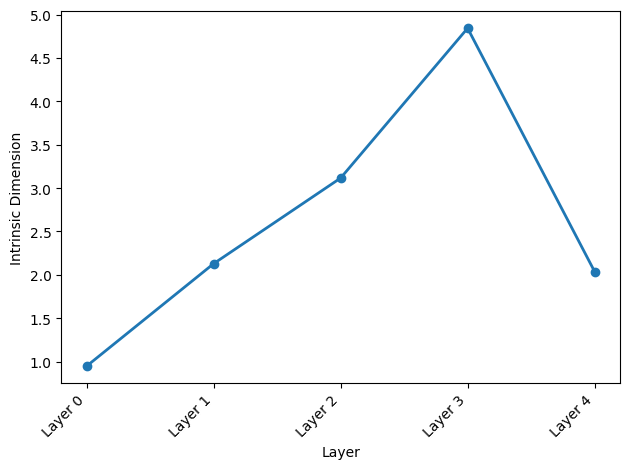

In [4]:
result, fig = pipe.reproduce(data)
result.describe()


## 3. Paper-specific follow-up plot


  line (d=1)         estimated d = 0.95  (true 1)
  plane (d=2)        estimated d = 2.13  (true 2)
  cube (d=3)         estimated d = 3.12  (true 3)
  cube (d=5)         estimated d = 4.84  (true 5)
  swiss roll (d=2)   estimated d = 2.04  (true 2)


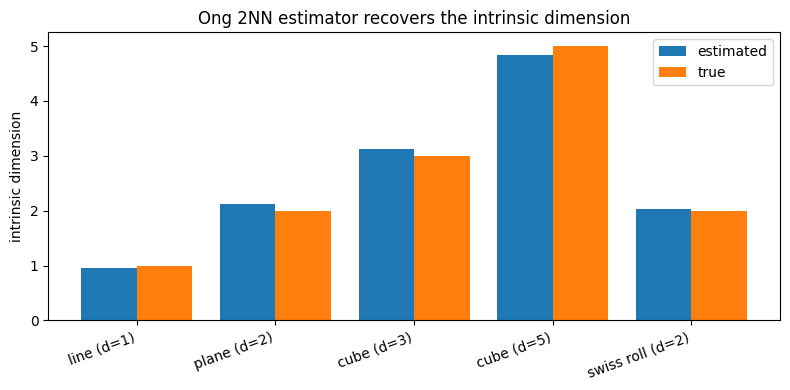

In [5]:
# The estimator returns one intrinsic dimension per cloud.
est = result.dimension_result['id_estimates']
for name, e, td in zip(manifolds, est, true_dims):
    print(f'  {name:18s} estimated d = {e:.2f}  (true {td})')

names = list(manifolds); x = np.arange(len(names))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, est, 0.4, label='estimated')
plt.bar(x + 0.2, true_dims, 0.4, label='true')
plt.xticks(x, names, rotation=20, ha='right'); plt.ylabel('intrinsic dimension')
plt.legend(); plt.title('Ong 2NN estimator recovers the intrinsic dimension')
plt.tight_layout(); plt.show()


## 4. Apply to a real neural network

The manifolds above validate that the estimator recovers a *known* dimension.
The paper's estimator is not tied to synthetic data, though — its natural use in
deep learning is to measure the **intrinsic dimension of each hidden layer's
activation cloud**. Here we train a small MLP on MNIST and run the *same*
`from_paper("ong2026")` pipeline on the per-layer activations via
`fit_model(...)`. The expected signature is that the intrinsic dimension
**compresses with depth** as the network folds the 784-dim input onto a
low-dimensional class manifold.

Requires the MNIST files under `data/MNIST/` (see `DATASETS.md`) and PyTorch.

In [6]:
import torch
from paper_reproduce._torch_setup import (
    load_mnist, SmallMLP, train_briefly, accuracy, pick_device,
)
torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'

# Train a small MLP briefly on MNIST (784 → 256 → 128 → 64 → 10).
X_tr, y_tr = load_mnist('train', n_samples=2000)
X_te, y_te = load_mnist('test',  n_samples=500)
model = SmallMLP(input_dim=784, hidden_dims=[256, 128, 64], output_dim=10)
train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=3,
              aspects=['activations'], device=DEVICE, verbose=False)
print(f'test accuracy: {accuracy(model, X_te, y_te, device=DEVICE):.3f}')

# Same preset, real data: intrinsic dimension of each layer's activation cloud.
nn_result = pipe.fit_model(model, X_te[:300],
                           representation='activations',
                           layer_selection='linear_and_conv')
nn_lid = nn_result.dimension_result['id_estimates']
for lbl, d in zip(nn_result.dimension_result['layer_labels'], nn_lid):
    print(f'  {lbl}: intrinsic dimension = {d:.2f}')


test accuracy: 0.822


  Layer 0: intrinsic dimension = 8.41
  Layer 1: intrinsic dimension = 6.00
  Layer 2: intrinsic dimension = 5.60
  Layer 3: intrinsic dimension = 5.58


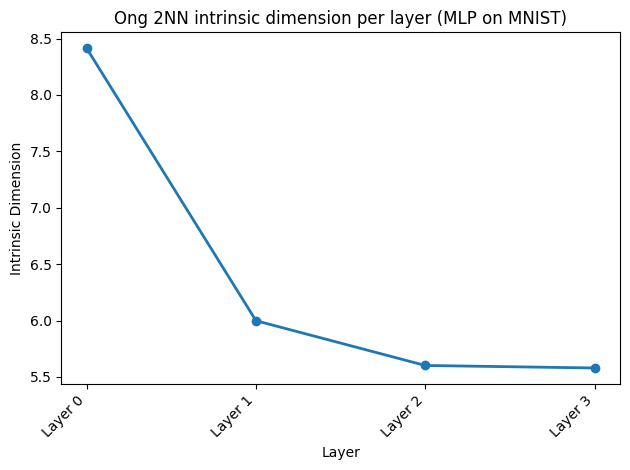

In [7]:
# The pipeline's default plot for this preset is the per-layer ID curve.
fig = nn_result.plot('id_layers')
fig.axes[0].set_title('Ong 2NN intrinsic dimension per layer (MLP on MNIST)')
plt.tight_layout(); plt.show()


## Notes & gaps

* **Synthetic benchmark (§1–3):** the parameter-free, sample-size-calibrated 2NN
  estimator recovers d≈1, 2, 3, 5 and the swiss roll's d≈2 with no tuning. Higher
  dimensions are mildly under-estimated with finite samples (a known 2NN
  property) — raise the sample count to tighten them.
* **Real neural network (§4):** the *same* pipeline applied to a trained MLP's
  activations shows the intrinsic dimension **compressing with depth** — the
  network progressively folds the 784-dim input onto a low-dimensional class
  manifold. Swap in any `torch.nn.Module` (or a `ModelSnapshot`) and
  `layer_selection` to profile your own architecture.
* The paper itself involves no neural network; §4 is a downstream application of
  its estimator, not a figure from the paper.

## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
